In [1]:
# 구글드라이브 연결

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from torchvision import transforms

Mounted at /content/drive


In [2]:
# 데이터 경로 설정

import os

DATA_DIR = "/content/drive/MyDrive/[시냅스] 서울 랜드마크 이미지 분류 모델/2026-1 시냅스 활동"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUBMISSION = os.path.join(DATA_DIR, "sample_submission.csv")

In [3]:
print(os.path.exists(DATA_DIR))
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.path.exists(TRAIN_CSV))
print(os.path.exists(TEST_CSV))

True
True
True
True
True


In [4]:
# csv 파일 읽기

import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)

print("train.csv 크기:", train_df.shape)
print("test.csv 크기:", test_df.shape)
print("sample_submission.csv 크기:", sample_submission.shape)

display(train_df.head())
display(test_df.head())
display(sample_submission.head())

train.csv 크기: (723, 2)
test.csv 크기: (199, 1)
sample_submission.csv 크기: (199, 2)


,file_name,label
0,001.PNG,9
1,002.PNG,4
2,003.PNG,1
3,004.PNG,1
4,005.PNG,6


,file_name
0,001.PNG
1,002.PNG
2,003.PNG
3,004.PNG
4,005.PNG


,file_name,label
0,001.PNG,2
1,002.PNG,1
2,003.PNG,5
3,004.PNG,7
4,005.PNG,6


In [5]:
# 데이터 컬럼 확인
# file_name: 이미지 파일 이름
# label: 이미지의 정답 클래스

# 컬럼명 지정
IMAGE_COL = "file_name"
LABEL_COL = "label"


# 이미지 경로 생성
train_df["image_path"] = train_df[IMAGE_COL].apply(
    lambda x: os.path.join(TRAIN_DIR, x)
)

test_df["image_path"] = test_df[IMAGE_COL].apply(
    lambda x: os.path.join(TEST_DIR, x)
)

display(train_df.head())
display(test_df.head())

,file_name,label,image_path
0,001.PNG,9,/content/drive/MyDrive/[시냅스] 서울 랜드마...
1,002.PNG,4,/content/drive/MyDrive/[시냅스] 서울 랜드마...
2,003.PNG,1,/content/drive/MyDrive/[시냅스] 서울 랜드마...
3,004.PNG,1,/content/drive/MyDrive/[시냅스] 서울 랜드마...
4,005.PNG,6,/content/drive/MyDrive/[시냅스] 서울 랜드마...


,file_name,image_path
0,001.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...
1,002.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...
2,003.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...
3,004.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...
4,005.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...


In [6]:
# 이미지 파일 존재 확인

print(train_df.loc[0, "image_path"])
print(os.path.exists(train_df.loc[0, "image_path"]))

print(test_df.loc[0, "image_path"])
print(os.path.exists(test_df.loc[0, "image_path"]))

/content/drive/MyDrive/[시냅스] 서울 랜드마크 이미지 분류 모델/2026-1 시냅스 활동/train/001.PNG
True
/content/drive/MyDrive/[시냅스] 서울 랜드마크 이미지 분류 모델/2026-1 시냅스 활동/test/001.PNG
True


In [7]:
# 클래스 확인, 라벨 정리

classes = sorted(train_df[LABEL_COL].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

train_df["label_idx"] = train_df[LABEL_COL].map(class_to_idx)

print("클래스 개수:", len(classes))
print("클래스 목록:", classes)

display(train_df.head())

클래스 개수: 10
클래스 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,file_name,label,image_path,label_idx
0,001.PNG,9,/content/drive/MyDrive/[시냅스] 서울 랜드마...,9
1,002.PNG,4,/content/drive/MyDrive/[시냅스] 서울 랜드마...,4
2,003.PNG,1,/content/drive/MyDrive/[시냅스] 서울 랜드마...,1
3,004.PNG,1,/content/drive/MyDrive/[시냅스] 서울 랜드마...,1
4,005.PNG,6,/content/drive/MyDrive/[시냅스] 서울 랜드마...,6


In [8]:
# 1. train / validation 분리

from sklearn.model_selection import train_test_split

train_data, valid_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label_idx"]
)

print("학습 데이터 개수:", len(train_data))
print("검증 데이터 개수:", len(valid_data))

학습 데이터 개수: 578
검증 데이터 개수: 145


In [9]:
# 2. 이미지 전처리
# transform: AI가 이미지를 보기 좋게 바꾸는 작업

from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),  # 모든 이미지 크기 통일

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),  # 이미지를 PyTorch tensor로 변환

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
# 3. CustomDataset 만들기

from PIL import Image
import torch
from torch.utils.data import Dataset

class LandmarkDataset(Dataset):

    def __init__(self, dataframe, transform=None, is_test=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image

        label = self.dataframe.loc[idx, "label_idx"]
        label = torch.tensor(label, dtype=torch.long)

        return image, label

- LandmarkDataset
    - 이미지 경로 확인
    - → 이미지 열기
    - → 전처리 적용
    - → 이미지와 라벨 반환

In [11]:
# 4. Dataset 생성

train_dataset = LandmarkDataset(
    train_data,
    transform=train_transform,
    is_test=False
)

valid_dataset = LandmarkDataset(
    valid_data,
    transform=valid_transform,
    is_test=False
)

test_dataset = LandmarkDataset(
    test_df,
    transform=valid_transform,
    is_test=True
)

print("train_dataset 개수:", len(train_dataset))
print("valid_dataset 개수:", len(valid_dataset))
print("test_dataset 개수:", len(test_dataset))

train_dataset 개수: 578
valid_dataset 개수: 145
test_dataset 개수: 199


In [12]:
# 5. DataLoader 생성

from torch.utils.data import DataLoader

# 32장씩 묶어서 모델에게 전달함
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True # 32장씩 묶어서 모델에게 전닳
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoader 생성 완료!")

DataLoader 생성 완료!


In [13]:
# 6. DataLoader 확인 코드

images, labels = next(iter(train_loader))

print("이미지 배치 크기:", images.shape)
print("라벨 배치 크기:", labels.shape)
print("첫 번째 라벨:", labels[0])

이미지 배치 크기: torch.Size([32, 3, 224, 224])
라벨 배치 크기: torch.Size([32])
첫 번째 라벨: tensor(9)


### 데이터 증강 실험

#### 실험1 증강 없는 버전

In [14]:
# 실험1 증강 없는 버전

basic_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
# 데이터셋

basic_train_dataset = LandmarkDataset(
    train_data,
    transform=basic_transform,
    is_test=False
)

basic_valid_dataset = LandmarkDataset(
    valid_data,
    transform=valid_transform,
    is_test=False
)

In [16]:
# DataLoader

basic_train_loader = DataLoader(
    basic_train_dataset,
    batch_size=32,
    shuffle=True
)

basic_valid_loader = DataLoader(
    basic_valid_dataset,
    batch_size=32,
    shuffle=False
)

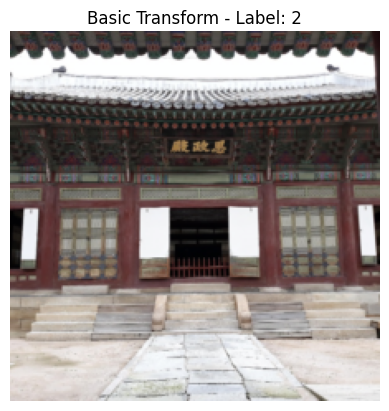

In [17]:
import matplotlib.pyplot as plt

image, label = basic_train_dataset[0]

image = image.permute(1, 2, 0).numpy()

image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
image = image.clip(0, 1)

plt.imshow(image)
plt.title(f"Basic Transform - Label: {label}")
plt.axis("off")
plt.show()

#### 실험2 기본 증강 버전

In [18]:
# 실험2 기본 증강 버전

aug_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),  # -10도 ~ +10도

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
# 데이터셋

aug_train_dataset = LandmarkDataset(
    train_data,
    transform=aug_transform,
    is_test=False
)

aug_valid_dataset = LandmarkDataset(
    valid_data,
    transform=valid_transform,
    is_test=False
)

In [20]:
# DataLoader

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=32,
    shuffle=True
)

aug_valid_loader = DataLoader(
    aug_valid_dataset,
    batch_size=32,
    shuffle=False
)

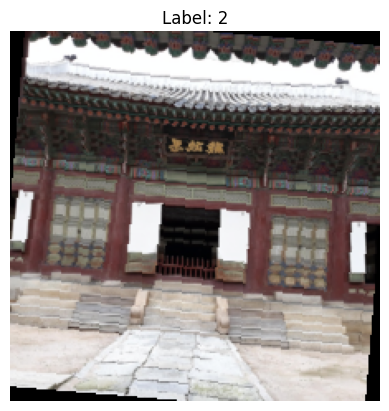

In [21]:
import matplotlib.pyplot as plt

image, label = aug_train_dataset[0]

image = image.permute(1, 2, 0).numpy()

image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
image = image.clip(0, 1)

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

#### ColorJitter

In [22]:
strong_aug_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

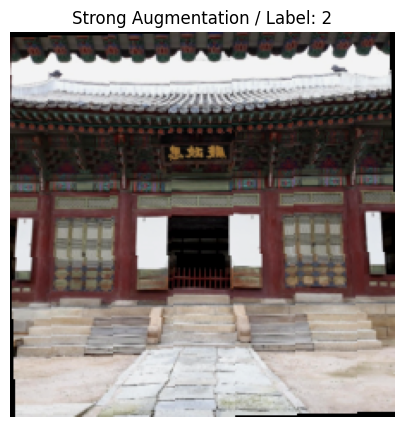

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# strong augmentation dataset 생성
strong_aug_train_dataset = LandmarkDataset(
    train_data,
    transform=strong_aug_transform,
    is_test=False
)

# 이미지 가져오기
image, label = strong_aug_train_dataset[0]

# tensor -> numpy 변환
image = image.permute(1, 2, 0).numpy()

# 정규화 복원
image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])

# 픽셀 범위 조정
image = image.clip(0, 1)

# 시각화
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title(f"Strong Augmentation / Label: {label}")
plt.axis("off")
plt.show()

| 종류                  | 적용 내용                                   |
| ------------------- | --------------------------------------- |
| Basic Transform     | Resize + Normalize                      |
| Basic Augmentation  | HorizontalFlip + Rotation               |
| Strong Augmentation | HorizontalFlip + Rotation + ColorJitter |


B파트- 김예지

CNN 모델정의


In [24]:
# 1. 기본 CNN 모델 정의
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용하는 디바이스: {device}")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

현재 사용하는 디바이스: cuda


학습 및 검증 함수 정의

In [25]:
# 2. 학습 및 검증 함수 정의
def train_and_validate(model, train_loader, valid_loader, criterion, optimizer, epochs, device):
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        model.eval()
        val_loss = 0.0
        corrects = 0

        with torch.no_grad():
            for images, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)

        val_loss = val_loss / len(valid_loader.dataset)
        val_acc = corrects.double() / len(valid_loader.dataset)

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = model.state_dict().copy()

    model.load_state_dict(best_model_weights)
    print(f"=== Best Validation Accuracy: {best_val_acc:.4f} ===")
    return model, history, best_val_acc.item()

하이퍼파라미터 튜닝

In [26]:
# 3. 하이퍼파라미터 튜닝
def get_dataloaders(batch_size):
    train_loader = DataLoader(basic_train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(basic_valid_dataset, batch_size=batch_size, shuffle=False)
    test_loader_local = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader_local

experiments = [
    {"name": "Exp 1", "batch_size": 32, "lr": 1e-3, "optimizer": "Adam"},
    {"name": "Exp 2", "batch_size": 16, "lr": 1e-2, "optimizer": "SGD"},
    {"name": "Exp 3", "batch_size": 64, "lr": 1e-4, "optimizer": "AdamW"}
]

epochs = 10
criterion = nn.CrossEntropyLoss()
results = {}
best_overall_model = None
best_overall_acc = 0.0
best_test_loader = None

for exp in experiments:
    print(f"\n[{exp['name']} 시작] Batch Size: {exp['batch_size']}, LR: {exp['lr']}, Optimizer: {exp['optimizer']}")

    train_loader, valid_loader, test_loader_local = get_dataloaders(exp['batch_size'])

    model = SimpleCNN(num_classes=10).to(device)

    if exp['optimizer'] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=exp['lr'])
    elif exp['optimizer'] == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=exp['lr'], momentum=0.9)
    elif exp['optimizer'] == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=exp['lr'])

    trained_model, history, best_acc = train_and_validate(
        model, train_loader, valid_loader, criterion, optimizer, epochs, device
    )

    results[exp['name']] = best_acc

    if best_acc > best_overall_acc:
        best_overall_acc = best_acc
        best_overall_model = trained_model
        best_test_loader = test_loader_local

print("\n=== 실험 결과 요약 (No Augmentation Baseline) ===")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")


[Exp 1 시작] Batch Size: 32, LR: 0.001, Optimizer: Adam


Epoch 1/10 [Train]:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 26.3481 | Val Loss: 5.3013 | Val Acc: 0.7103


Epoch 2/10 [Train]:   0%|          | 0/19 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.0762 | Val Loss: 0.1394 | Val Acc: 0.9586


Epoch 10/10 [Train]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.0784 | Val Loss: 0.1355 | Val Acc: 0.9793
=== Best Validation Accuracy: 0.9793 ===

=== 실험 결과 요약 (No Augmentation Baseline) ===
Exp 1: 0.9586
Exp 2: 0.2966
Exp 3: 0.9793


## 데이터 증강 방식 비교

In [27]:
# 동일한 SimpleCNN 구조와 하이퍼파라미터를 사용
# train transform만 다르게 하여 validation accuracy를 비교

augmentation_experiments = [
    {
        "name": "No Augmentation",
        "train_dataset": basic_train_dataset
    },
    {
        "name": "Basic Augmentation",
        "train_dataset": aug_train_dataset
    },
    {
        "name": "Strong Augmentation",
        "train_dataset": strong_aug_train_dataset
    },
]

augmentation_results = {}

AUG_BATCH_SIZE = 64
AUG_LR = 1e-4
AUG_EPOCHS = 10

for aug_exp in augmentation_experiments:
    print(f"\n[{aug_exp['name']} 실험 시작]")

    aug_train_loader = DataLoader(
        aug_exp["train_dataset"],
        batch_size=AUG_BATCH_SIZE,
        shuffle=True
    )

    # 검증 데이터에는 augmentation을 적용하지 않음
    aug_valid_loader = DataLoader(
        basic_valid_dataset,
        batch_size=AUG_BATCH_SIZE,
        shuffle=False
    )

    model = SimpleCNN(num_classes=10).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=AUG_LR)

    trained_model, history, best_acc = train_and_validate(
        model,
        aug_train_loader,
        aug_valid_loader,
        criterion,
        optimizer,
        epochs=AUG_EPOCHS,
        device=device
    )

    augmentation_results[aug_exp["name"]] = best_acc

print("\n=== 데이터 증강 방식별 성능 비교 결과 ===")
for name, acc in augmentation_results.items():
    print(f"{name}: {acc:.4f}")



[No Augmentation 실험 시작]


Epoch 1/10 [Train]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 3.5200 | Val Loss: 1.7175 | Val Acc: 0.3793


Epoch 2/10 [Train]:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.3631 | Val Loss: 0.2649 | Val Acc: 0.9517


Epoch 10/10 [Train]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.3482 | Val Loss: 0.1833 | Val Acc: 0.9586
=== Best Validation Accuracy: 0.9586 ===

=== 데이터 증강 방식별 성능 비교 결과 ===
No Augmentation: 0.9724
Basic Augmentation: 0.9448
Strong Augmentation: 0.9586


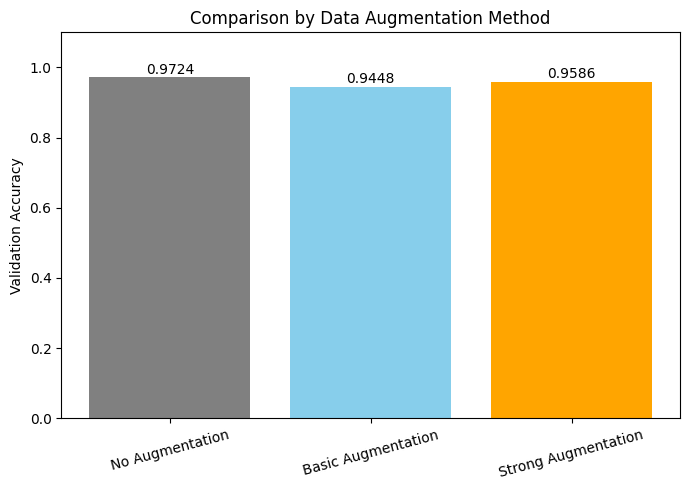

In [28]:
plt.figure(figsize=(7, 5))
bars = plt.bar(
    augmentation_results.keys(),
    augmentation_results.values(),
    color=["gray", "skyblue", "orange"]
)

plt.ylim(0, 1.1)
plt.ylabel("Validation Accuracy")
plt.title("Comparison by Data Augmentation Method")

for bar, acc in zip(bars, augmentation_results.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        acc + 0.01,
        f"{acc:.4f}",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

테스트 예측 및 submission_cnn.csv 생성

In [29]:
# 4. 테스트 예측 및 submission_cnn.csv 생성
best_overall_model.eval()
predictions = []

print("\n테스트 데이터 예측 진행 중...")
with torch.no_grad():
    for images in tqdm(best_test_loader, desc="Testing"):
        images = images.to(device)
        outputs = best_overall_model(images)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy())

predicted_classes = [idx_to_class[idx] for idx in predictions]

submission_df = sample_submission.copy()
submission_df[LABEL_COL] = predicted_classes

submission_file = "submission_cnn.csv"
submission_df.to_csv(submission_file, index=False)

print(f"\n{submission_file} 파일이 성공적으로 생성되었습니다!")
display(submission_df.head())


테스트 데이터 예측 진행 중...


Testing:   0%|          | 0/4 [00:00<?, ?it/s]


submission_cnn.csv 파일이 성공적으로 생성되었습니다!


,file_name,label
0,001.PNG,7
1,002.PNG,1
2,003.PNG,0
3,004.PNG,7
4,005.PNG,6


## C_part
전이학습 기반 이미지 분류 모델 구현

In [30]:
import torchvision.models as models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import copy


In [31]:
# 전이학습용 transform (Strong Augmentation으로 과적합 방지)
transfer_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transfer_valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transfer_train_dataset = LandmarkDataset(train_data, transform=transfer_train_transform, is_test=False)
transfer_valid_dataset = LandmarkDataset(valid_data, transform=transfer_valid_transform, is_test=False)
transfer_test_dataset  = LandmarkDataset(test_df,    transform=transfer_valid_transform, is_test=True)

transfer_train_loader = DataLoader(transfer_train_dataset, batch_size=32, shuffle=True)
transfer_valid_loader = DataLoader(transfer_valid_dataset, batch_size=32, shuffle=False)
transfer_test_loader  = DataLoader(transfer_test_dataset,  batch_size=32, shuffle=False)

print("DataLoader 준비 완료!")

DataLoader 준비 완료!


In [32]:
# 전이학습용 학습 함수 (EarlyStopping 추가)
# EarlyStopping: val_acc가 patience 에폭 동안 개선 없으면 조기 종료 → 과적합 방지
def train_and_validate_transfer(model, train_loader, valid_loader, criterion, optimizer,
                                epochs, device, patience=5):
    best_val_acc     = 0.0
    best_weights     = None
    no_improve_count = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        model.eval()
        val_loss, corrects = 0.0, 0
        with torch.no_grad():
            for images, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs   = model(images)
                val_loss += criterion(outputs, labels).item() * images.size(0)
                _, preds  = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data).item()

        val_loss /= len(valid_loader.dataset)
        val_acc   = corrects / len(valid_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            best_weights     = copy.deepcopy(model.state_dict())  # 진짜 best 시점 가중치 저장
            no_improve_count = 0
        else:
            no_improve_count += 1
            if no_improve_count >= patience:
                print(f"  → EarlyStopping: {patience} 에폭 동안 개선 없음. 학습 종료.")
                break

    model.load_state_dict(best_weights)
    print(f"=== Best Validation Accuracy: {best_val_acc:.4f} ===")
    return model, history, best_val_acc

In [33]:
criterion           = nn.CrossEntropyLoss()
transfer_results    = {}
best_transfer_model = None
best_transfer_acc   = 0.0

transfer_experiments = [
    # ResNet18 — freeze 전략 3가지
    {"name": "Exp A - ResNet18 Feature Extraction",  "model": "resnet18", "freeze": "all",     "epochs": 15, "patience": 5},
    {"name": "Exp B - ResNet18 Partial Fine-tuning", "model": "resnet18", "freeze": "partial", "epochs": 15, "patience": 5},
    {"name": "Exp C - ResNet18 Full Fine-tuning",    "model": "resnet18", "freeze": "none",    "epochs": 15, "patience": 5},
    # ResNet50
    {"name": "Exp D - ResNet50 Feature Extraction",  "model": "resnet50", "freeze": "all",     "epochs": 10, "patience": 4},
    {"name": "Exp E - ResNet50 Partial Fine-tuning", "model": "resnet50", "freeze": "partial", "epochs": 10, "patience": 4},
    {"name": "Exp F - ResNet50 Full Fine-tuning",    "model": "resnet50", "freeze": "none",    "epochs": 10, "patience": 4},
]

for exp in transfer_experiments:
    print(f"\n{'='*50}")
    print(f"[{exp['name']} 시작] epochs={exp['epochs']}")

    if exp["model"] == "resnet18":
        model = models.resnet18(weights="IMAGENET1K_V1")
        model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(model.fc.in_features, 10)
        )
    else:
        model = models.resnet50(weights="IMAGENET1K_V1")
        model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(model.fc.in_features, 10)
        )
    model = model.to(device)

    if exp["freeze"] == "all":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
    elif exp["freeze"] == "partial":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True
    elif exp["freeze"] == "none":
        for param in model.parameters():
            param.requires_grad = True

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
    )

    trained_model, history, best_acc = train_and_validate_transfer(
        model, transfer_train_loader, transfer_valid_loader,
        criterion, optimizer, epochs=exp["epochs"], device=device, patience=exp["patience"]
    )

    transfer_results[exp["name"]] = best_acc

    if best_acc > best_transfer_acc:
        best_transfer_acc   = best_acc
        best_transfer_model = trained_model

print("\n=== 전이학습 실험 결과 요약 ===")
for name, acc in transfer_results.items():
    print(f"{name}: {acc:.4f}")


[Exp A - ResNet18 Feature Extraction 시작] epochs=15
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


Epoch 1/15 [Train]:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 1/15 [Valid]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 2.5725 | Val Loss: 2.3604 | Val Acc: 0.1586


...

Epoch 5/10 [Valid]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 5/10 | Train Loss: 0.0244 | Val Loss: 0.0126 | Val Acc: 1.0000


Epoch 6/10 [Train]:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 6/10 [Valid]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 6/10 | Train Loss: 0.0188 | Val Loss: 0.0075 | Val Acc: 1.0000
  → EarlyStopping: 4 에폭 동안 개선 없음. 학습 종료.
=== Best Validation Accuracy: 1.0000 ===

=== 전이학습 실험 결과 요약 ===
Exp A - ResNet18 Feature Extraction: 0.8276
Exp B - ResNet18 Partial Fine-tuning: 1.0000
Exp C - ResNet18 Full Fine-tuning: 1.0000
Exp D - ResNet50 Feature Extraction: 0.9724
Exp E - ResNet50 Partial Fine-tuning: 1.0000
Exp F - ResNet50 Full Fine-tuning: 1.0000


In [34]:
# submission_transfer.csv 생성
best_transfer_model.eval()
predictions = []

with torch.no_grad():
    for images in tqdm(transfer_test_loader, desc="Testing"):
        images = images.to(device)
        outputs = best_transfer_model(images)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy())

predicted_classes = [idx_to_class[idx] for idx in predictions]
submission_transfer = sample_submission.copy()
submission_transfer[LABEL_COL] = predicted_classes
submission_transfer.to_csv("submission_transfer.csv", index=False)

print("submission_transfer.csv 저장 완료")
display(submission_transfer.head())

Testing:   0%|          | 0/7 [00:00<?, ?it/s]

submission_transfer.csv 저장 완료


,file_name,label
0,001.PNG,7
1,002.PNG,1
2,003.PNG,9
3,004.PNG,7
4,005.PNG,6


Confusion Matrix:   0%|          | 0/5 [00:00<?, ?it/s]

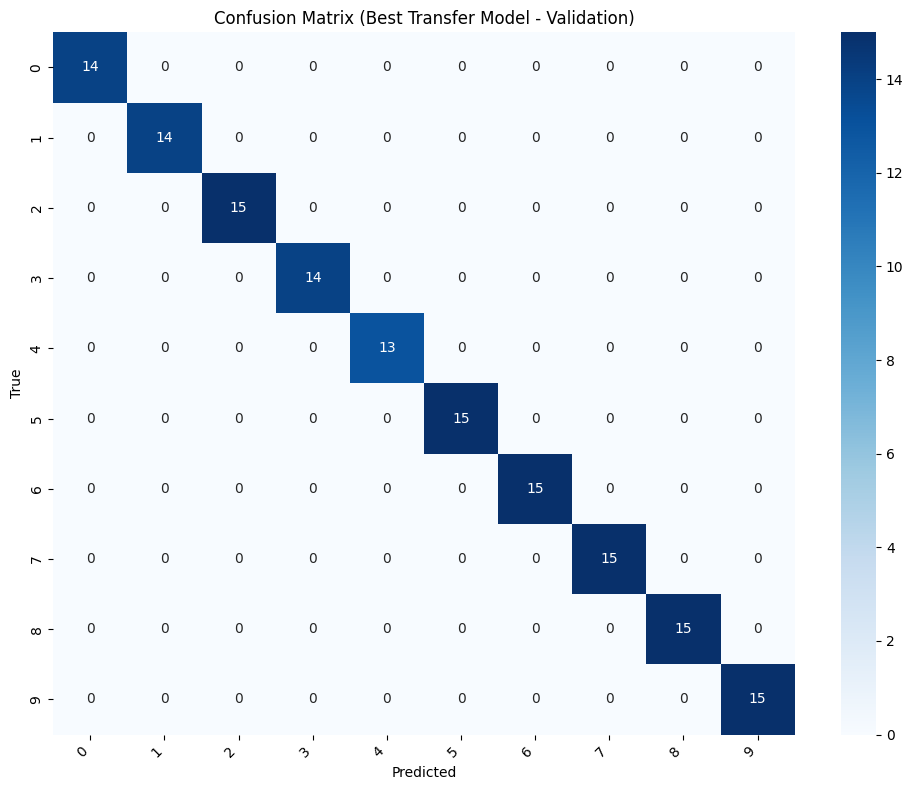


=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        14
           4       1.00      1.00      1.00        13
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00        15
           8       1.00      1.00      1.00        15
           9       1.00      1.00      1.00        15

    accuracy                           1.00       145
   macro avg       1.00      1.00      1.00       145
weighted avg       1.00      1.00      1.00       145


=== Class Accuracy ===
  0                             : 1.0000  (14/14)
  1                             : 1.0000  (14/14)
  2                             : 1.0000  (15/15)
  3                             : 1.

In [35]:
# Confusion Matrix 및 오분류 분석
import math

classes_list = [str(c) for c in classes]

best_transfer_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(transfer_valid_loader, desc="Confusion Matrix"):
        images = images.to(device)
        _, preds = torch.max(best_transfer_model(images), 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion Matrix 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_list, yticklabels=classes_list)
plt.title("Confusion Matrix (Best Transfer Model - Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=classes_list))

# 클래스별 Accuracy
class_correct = np.diag(cm)
class_total   = cm.sum(axis=1)
print("\n=== Class Accuracy ===")
for cls, c, t in zip(classes_list, class_correct, class_total):
    print(f"  {cls:30s}: {c/t:.4f}  ({c}/{t})")

# 가장 많이 혼동한 클래스 쌍 Top 5
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top5 = np.argsort(cm_no_diag.ravel())[::-1][:5]
print("\n=== Most Confused Class Pairs Top 5 ===")
for idx in top5:
    tc = classes_list[idx // len(classes_list)]
    pc = classes_list[idx  % len(classes_list)]
    print(f"  True: {tc:25s} → Pred: {pc:25s} ({cm_no_diag.ravel()[idx]}건)")

In [36]:
# 모델 파라미터 수 비교
resnet18_temp = models.resnet18(weights=None)
resnet50_temp = models.resnet50(weights=None)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("=== 모델 파라미터 수 비교 ===")
print(f"ResNet18:  {count_params(resnet18_temp):,} 개")
print(f"ResNet50:  {count_params(resnet50_temp):,} 개")
print(f"SimpleCNN: 약 4,000,000 개")

=== 모델 파라미터 수 비교 ===
ResNet18:  11,689,512 개
ResNet50:  25,557,032 개
SimpleCNN: 약 4,000,000 개


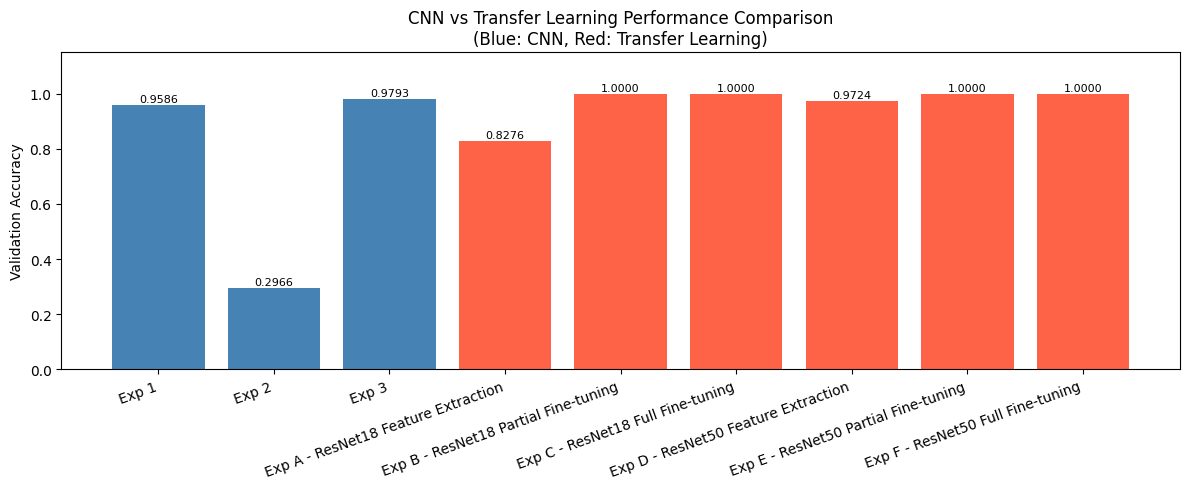


Best CNN Accuracy:      0.9793
Best Transfer Accuracy: 1.0000
Improvement:            +0.0207


In [37]:
# CNN vs 전이학습 전체 성능 비교
labels_plot = list(results.keys()) + list(transfer_results.keys())
accs_plot   = list(results.values()) + list(transfer_results.values())
colors      = ['steelblue'] * len(results) + ['tomato'] * len(transfer_results)

plt.figure(figsize=(12, 5))
bars = plt.bar(labels_plot, accs_plot, color=colors)
plt.ylim(0, 1.15)
plt.ylabel("Validation Accuracy")
plt.title("CNN vs Transfer Learning Performance Comparison\n(Blue: CNN, Red: Transfer Learning)")
for bar, acc in zip(bars, accs_plot):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.4f}", ha='center', fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(f"\nBest CNN Accuracy:      {best_overall_acc:.4f}")
print(f"Best Transfer Accuracy: {best_transfer_acc:.4f}")
print(f"Improvement:            {best_transfer_acc - best_overall_acc:+.4f}")